# 🎯 Customer Churn — Ensemble v6
**Kaggle Playground Series 2026**

Three diverse models + hill climbing blend:
1. **LightGBM** — best params from v5 (lr=0.04, num_leaves=29, lambda_l2=150, min_child_samples=100)
2. **XGBoost** — different boosting implementation, adds diversity
3. **MLP** — simple neural net, fundamentally different model family
4. **Hill Climbing** — OOF-optimised blend weights

### Structure
1. Setup & Load
2. LightGBM — 5-fold CV
3. XGBoost — 5-fold CV
4. MLP — 5-fold CV
5. Hill Climbing — blend weight optimisation
6. OOF Analysis
7. Submission

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED    = 42
N_FOLDS = 5

DATA_DIR = "/Users/clairedebadts/kaggle/customer-churn/data/processed/"
OUT_DIR  = "/Users/clairedebadts/kaggle/customer-churn/"

X_train  = pd.read_csv(DATA_DIR + "X_train.csv").drop(columns=['risk_score'], errors='ignore')
y_train  = pd.read_csv(DATA_DIR + "y_train.csv").squeeze()
X_test   = pd.read_csv(DATA_DIR + "X_test.csv").drop(columns=['risk_score'], errors='ignore')
test_ids = pd.read_csv(DATA_DIR + "test_ids.csv")

FEATURE_COLS = X_train.columns.tolist()
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}  |  churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test  : {X_test.shape}")


X_train : (594194, 40)
y_train : (594194,)  |  churn rate: 22.52%
X_test  : (254655, 40)


---
## 2. LightGBM — 5-Fold CV

Best params from v5 tuning. 2000 rounds so slow learning rate converges fully.

In [2]:
params_lgb = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'learning_rate'    : 0.04,
    'num_leaves'       : 29,
    'max_depth'        : 6,
    'min_child_samples': 100,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.1,
    'lambda_l2'        : 150,
    'is_unbalance'     : True,
    'verbose'          : -1,
    'random_state'     : SEED,
}

oof_lgb  = np.zeros(len(X_train))
tst_lgb  = np.zeros(len(X_test))
scores_lgb = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params_lgb, dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(150, verbose=False),
            lgb.log_evaluation(200),
        ],
    )

    oof_lgb[val_idx] = model.predict(X_val)
    tst_lgb         += model.predict(X_test) / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_lgb[val_idx])
    scores_lgb.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration}")

auc_lgb = roc_auc_score(y_train, oof_lgb)
print(f"\n  LGB OOF AUC : {auc_lgb:.5f}")
print(f"  Mean        : {np.mean(scores_lgb):.5f} +/- {np.std(scores_lgb):.5f}")


[200]	valid_0's auc: 0.914437
[400]	valid_0's auc: 0.915409
[600]	valid_0's auc: 0.915752
[800]	valid_0's auc: 0.915891
[1000]	valid_0's auc: 0.915946
  Fold 1 — AUC: 0.91598 | best iter: 1045
[200]	valid_0's auc: 0.91554
[400]	valid_0's auc: 0.91649
[600]	valid_0's auc: 0.916756
[800]	valid_0's auc: 0.916983
[1000]	valid_0's auc: 0.91709
[1200]	valid_0's auc: 0.917135
[1400]	valid_0's auc: 0.917154
[1600]	valid_0's auc: 0.917173
[1800]	valid_0's auc: 0.917178
  Fold 2 — AUC: 0.91719 | best iter: 1695
[200]	valid_0's auc: 0.914866
[400]	valid_0's auc: 0.915879
[600]	valid_0's auc: 0.91622
[800]	valid_0's auc: 0.916416
[1000]	valid_0's auc: 0.916505
[1200]	valid_0's auc: 0.916554
[1400]	valid_0's auc: 0.916584
[1600]	valid_0's auc: 0.916607
[1800]	valid_0's auc: 0.916596
  Fold 3 — AUC: 0.91661 | best iter: 1701
[200]	valid_0's auc: 0.915979
[400]	valid_0's auc: 0.916912
[600]	valid_0's auc: 0.917259
[800]	valid_0's auc: 0.91746
[1000]	valid_0's auc: 0.917571
[1200]	valid_0's auc: 0.917

---
## 3. XGBoost — 5-Fold CV

Similar boosting family to LGB but different implementation — split finding,
regularisation, and tree building differ enough to produce uncorrelated errors.
`scale_pos_weight` handles class imbalance (equivalent to `is_unbalance` in LGB).

In [3]:
params_xgb = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'auc',
    'learning_rate'    : 0.04,
    'max_depth'        : 5,
    'min_child_weight' : 50,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 150,
    'scale_pos_weight' : (y_train==0).sum() / (y_train==1).sum(),
    'tree_method'      : 'hist',   # fast on CPU and GPU
    'random_state'     : SEED,
    'verbosity'        : 0,
}

oof_xgb   = np.zeros(len(X_train))
tst_xgb   = np.zeros(len(X_test))
scores_xgb = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval   = xgb.DMatrix(X_val, label=y_val)

    model = xgb.train(
        params_xgb,
        dtrain,
        num_boost_round=2000,
        evals=[(dval, 'val')],
        early_stopping_rounds=150,
        verbose_eval=200,
    )

    oof_xgb[val_idx] = model.predict(dval)
    tst_xgb         += model.predict(xgb.DMatrix(X_test)) / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_xgb[val_idx])
    scores_xgb.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration}")

auc_xgb = roc_auc_score(y_train, oof_xgb)
print(f"\n  XGB OOF AUC : {auc_xgb:.5f}")
print(f"  Mean        : {np.mean(scores_xgb):.5f} +/- {np.std(scores_xgb):.5f}")
print(f"  vs LGB      : {auc_xgb - auc_lgb:+.5f}")


[0]	val-auc:0.89680
[200]	val-auc:0.91417
[400]	val-auc:0.91521
[600]	val-auc:0.91565
[800]	val-auc:0.91586
[1000]	val-auc:0.91598
[1200]	val-auc:0.91606
[1400]	val-auc:0.91609
[1600]	val-auc:0.91612
[1800]	val-auc:0.91613
[1860]	val-auc:0.91613
  Fold 1 — AUC: 0.91613 | best iter: 1710
[0]	val-auc:0.89697
[200]	val-auc:0.91521
[400]	val-auc:0.91623
[600]	val-auc:0.91666
[800]	val-auc:0.91693
[1000]	val-auc:0.91707
[1200]	val-auc:0.91716
[1400]	val-auc:0.91722
[1600]	val-auc:0.91725
[1800]	val-auc:0.91727
[1999]	val-auc:0.91728
  Fold 2 — AUC: 0.91728 | best iter: 1997
[0]	val-auc:0.89675
[200]	val-auc:0.91468
[400]	val-auc:0.91580
[600]	val-auc:0.91620
[800]	val-auc:0.91642
[1000]	val-auc:0.91657
[1200]	val-auc:0.91664
[1400]	val-auc:0.91669
[1600]	val-auc:0.91671
[1800]	val-auc:0.91673
[1955]	val-auc:0.91671
  Fold 3 — AUC: 0.91671 | best iter: 1806
[0]	val-auc:0.89740
[200]	val-auc:0.91575
[400]	val-auc:0.91676
[600]	val-auc:0.91720
[800]	val-auc:0.91744
[1000]	val-auc:0.91754
[1200

---
## 4. MLP — 5-Fold CV

Simple neural network — fundamentally different model family from tree-based models.
Learns smooth decision boundaries vs tree models' step functions.
Errors are often uncorrelated with GBDT errors → high ensemble value.
StandardScaler essential — neural nets are sensitive to feature scale.

In [4]:
oof_mlp   = np.zeros(len(X_train))
tst_mlp   = np.zeros(len(X_test))
scores_mlp = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    # Scale within fold — no leakage
    scaler = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)
    X_tst_s = scaler.transform(X_test)

    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),  # 3 layers — deep enough to learn interactions
        activation='relu',
        solver='adam',
        alpha=0.01,                        # L2 regularisation
        batch_size=2048,                   # large batch — stable on 594k rows
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=SEED,
        verbose=False,
    )

    mlp.fit(X_tr_s, y_tr)

    oof_mlp[val_idx] = mlp.predict_proba(X_val_s)[:, 1]
    tst_mlp         += mlp.predict_proba(X_tst_s)[:, 1] / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_mlp[val_idx])
    scores_mlp.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f}")

auc_mlp = roc_auc_score(y_train, oof_mlp)
print(f"\n  MLP OOF AUC : {auc_mlp:.5f}")
print(f"  Mean        : {np.mean(scores_mlp):.5f} +/- {np.std(scores_mlp):.5f}")
print(f"  vs LGB      : {auc_mlp - auc_lgb:+.5f}")
print(f"  vs XGB      : {auc_mlp - auc_xgb:+.5f}")

# ── OOF correlation — diversity check ─────────────────────────────────────
# Low correlation between model errors = high ensemble value
print("\nOOF prediction correlation (lower = more diverse = better for ensemble):")
oof_df = pd.DataFrame({'LGB': oof_lgb, 'XGB': oof_xgb, 'MLP': oof_mlp})
print(oof_df.corr().round(4).to_string())


  Fold 1 — AUC: 0.91157
  Fold 2 — AUC: 0.91267
  Fold 3 — AUC: 0.91213
  Fold 4 — AUC: 0.91382
  Fold 5 — AUC: 0.91089

  MLP OOF AUC : 0.91216
  Mean        : 0.91222 +/- 0.00100
  vs LGB      : -0.00431
  vs XGB      : -0.00440

OOF prediction correlation (lower = more diverse = better for ensemble):
        LGB     XGB     MLP
LGB  1.0000  0.9987  0.9580
XGB  0.9987  1.0000  0.9578
MLP  0.9580  0.9578  1.0000


---
## 5. Hill Climbing — Blend Weight Optimisation

Find optimal weights for blending LGB + XGB + MLP predictions.
Algorithm:
- Start with equal weights [1/3, 1/3, 1/3]
- At each step, try adding a small increment to one model's weight
- If OOF AUC improves, keep the change
- Repeat until no single step improves AUC

Run entirely on OOF predictions — no data leakage.

In [5]:
def hill_climbing(oofs, y, n_iter=3000, step=0.01, seed=SEED):
    """
    Find optimal blend weights via hill climbing.

    oofs  : list of OOF prediction arrays [oof_lgb, oof_xgb, oof_mlp]
    y     : true labels
    n_iter: max iterations
    step  : increment size per step
    """
    n_models = len(oofs)
    weights  = np.array([1.0 / n_models] * n_models)

    best_blend = sum(w * o for w, o in zip(weights, oofs))
    best_auc   = roc_auc_score(y, best_blend)

    print(f"Starting AUC (equal weights): {best_auc:.5f}")
    print(f"  Initial weights: {[round(w,3) for w in weights]}\n")

    improved = True
    iteration = 0

    while improved and iteration < n_iter:
        improved = False
        iteration += 1

        for i in range(n_models):
            # Try increasing weight of model i
            new_weights = weights.copy()
            new_weights[i] += step
            new_weights = new_weights / new_weights.sum()  # renormalise

            blend = sum(w * o for w, o in zip(new_weights, oofs))
            auc   = roc_auc_score(y, blend)

            if auc > best_auc:
                best_auc   = auc
                weights    = new_weights
                improved   = True

    print(f"Hill climbing converged after {iteration} iterations")
    print(f"Best OOF AUC : {best_auc:.5f}")
    print(f"Best weights :")
    model_names = ['LGB', 'XGB', 'MLP']
    for name, w in zip(model_names, weights):
        print(f"  {name} : {w:.4f} ({w*100:.1f}%)")

    return weights, best_auc


# ── Run hill climbing ──────────────────────────────────────────────────────
oofs = [oof_lgb, oof_xgb, oof_mlp]
tsts = [tst_lgb, tst_xgb, tst_mlp]

best_weights, auc_blend = hill_climbing(oofs, y_train)

# ── Compare all options ────────────────────────────────────────────────────
print(f"\n{'='*45}")
print(f"  LGB alone   : {auc_lgb:.5f}")
print(f"  XGB alone   : {auc_xgb:.5f}")
print(f"  MLP alone   : {auc_mlp:.5f}")
print(f"  Equal blend : {roc_auc_score(y_train, sum(o/3 for o in oofs)):.5f}")
print(f"  Hill climb  : {auc_blend:.5f}  ← best")
print(f"  vs LGB alone: {auc_blend - auc_lgb:+.5f}")
print(f"{'='*45}")

# ── Final test predictions ─────────────────────────────────────────────────
tst_blend = sum(w * t for w, t in zip(best_weights, tsts))


Starting AUC (equal weights): 0.91597
  Initial weights: [0.333, 0.333, 0.333]

Hill climbing converged after 239 iterations
Best OOF AUC : 0.91662
Best weights :
  LGB : 0.3781 (37.8%)
  XGB : 0.6163 (61.6%)
  MLP : 0.0055 (0.6%)

  LGB alone   : 0.91647
  XGB alone   : 0.91656
  MLP alone   : 0.91216
  Equal blend : 0.91597
  Hill climb  : 0.91662  ← best
  vs LGB alone: +0.00016


---
## 6. OOF Analysis

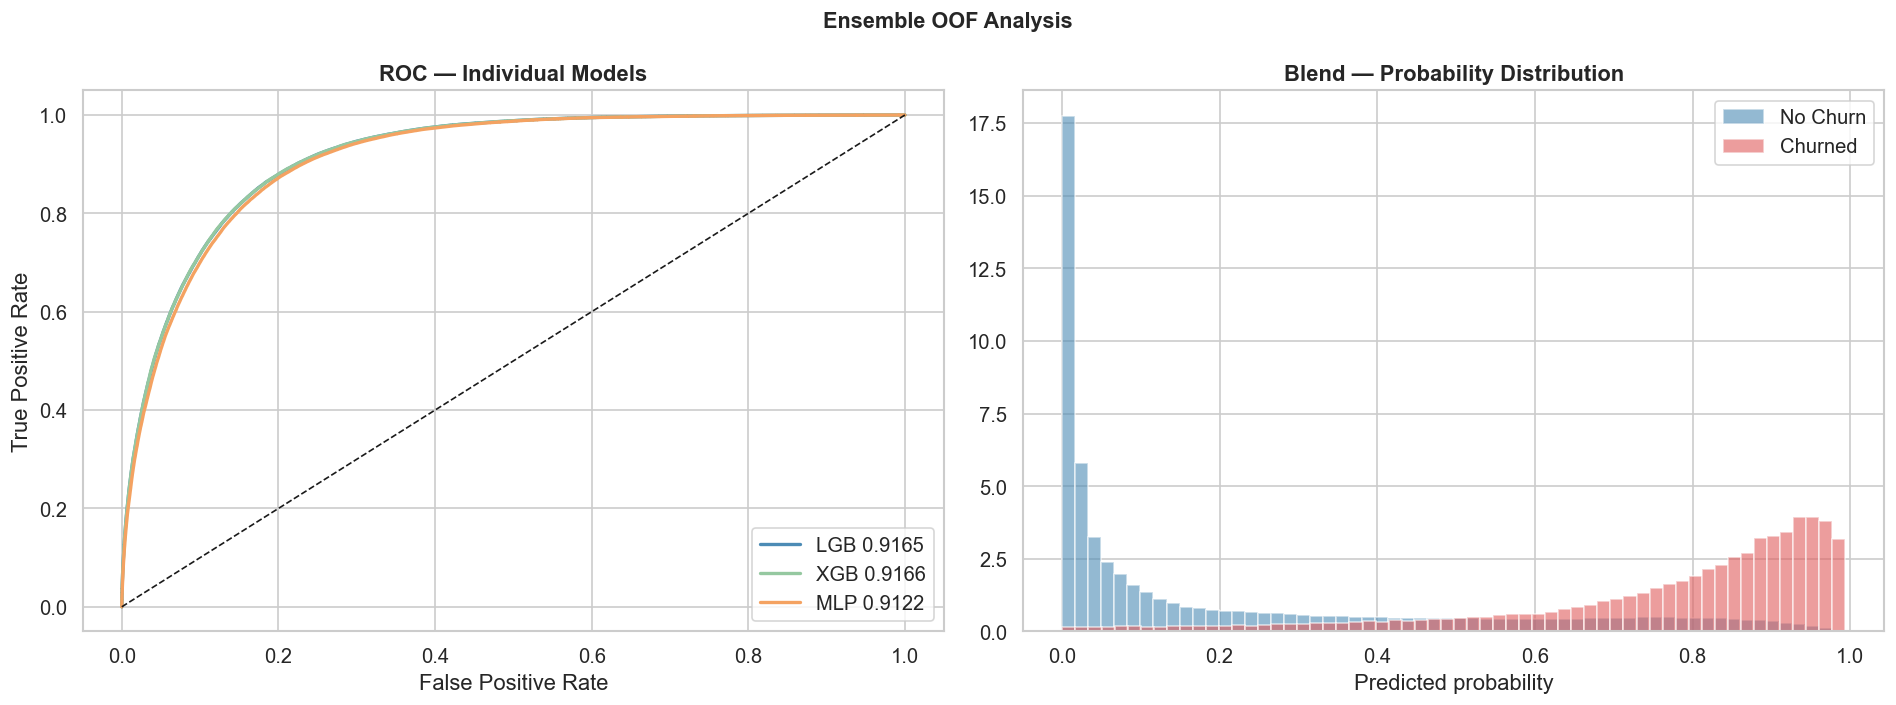

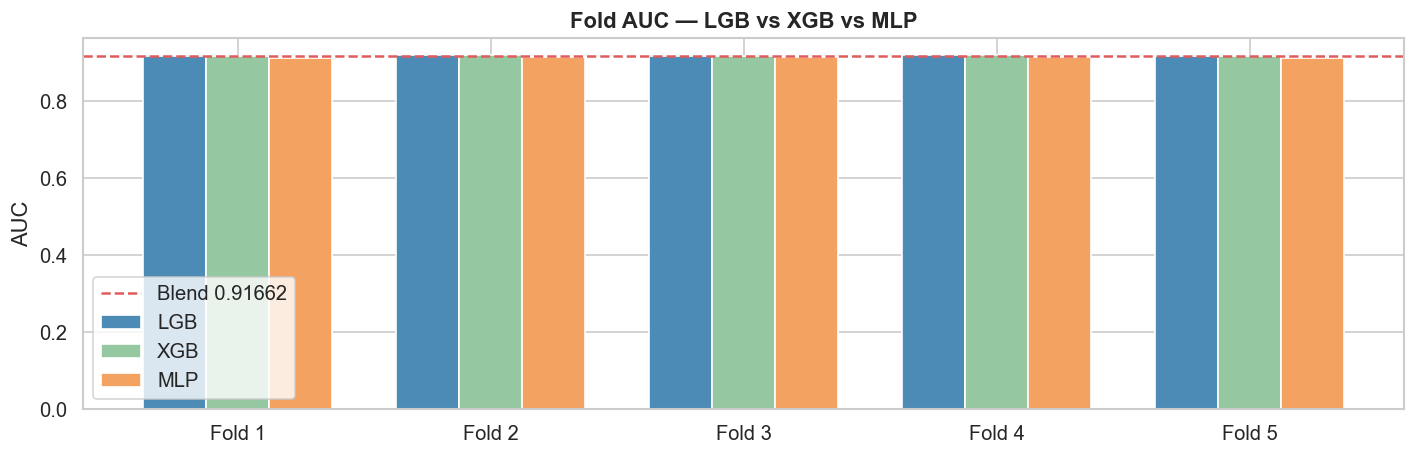

In [6]:
fpr_lgb, tpr_lgb, _ = roc_curve(y_train, oof_lgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_train, oof_xgb)
fpr_mlp, tpr_mlp, _ = roc_curve(y_train, oof_mlp)
fpr_bld, tpr_bld, _ = roc_curve(y_train, tst_blend if len(tst_blend) == len(y_train)
                                  else sum(w*o for w,o in zip(best_weights, oofs)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC curves — all models
for label, fpr, tpr, auc, color in [
    ('LGB',   fpr_lgb, tpr_lgb, auc_lgb, '#4C8BB5'),
    ('XGB',   fpr_xgb, tpr_xgb, auc_xgb, '#95C8A0'),
    ('MLP',   fpr_mlp, tpr_mlp, auc_mlp, '#F4A261'),
]:
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{label} {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--',linewidth=1)
axes[0].set_title('ROC — Individual Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Probability distributions — blend
oof_final = sum(w * o for w, o in zip(best_weights, oofs))
axes[1].hist(oof_final[y_train==0], bins=60, alpha=0.6,
             color='#4C8BB5', label='No Churn', density=True)
axes[1].hist(oof_final[y_train==1], bins=60, alpha=0.6,
             color='#E05C5C', label='Churned', density=True)
axes[1].set_title('Blend — Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted probability')
axes[1].legend()

plt.suptitle('Ensemble OOF Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Fold stability comparison
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(N_FOLDS)
w = 0.25
ax.bar(x - w,   scores_lgb, width=w, label='LGB', color='#4C8BB5', edgecolor='white')
ax.bar(x,       scores_xgb, width=w, label='XGB', color='#95C8A0', edgecolor='white')
ax.bar(x + w,   scores_mlp, width=w, label='MLP', color='#F4A261', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(1, N_FOLDS+1)])
ax.axhline(auc_blend, color='#E05C5C', linestyle='--',
           linewidth=1.5, label=f'Blend {auc_blend:.5f}')
ax.set_title('Fold AUC — LGB vs XGB vs MLP', fontweight='bold')
ax.set_ylabel('AUC')
ax.legend()
plt.tight_layout()
plt.show()


---
## 7. Submission

Sanity checks: ✅
Rows      : 254,655
Churn mean: 0.3404  (train: 0.2252)

Final summary:
  LGB alone  : OOF 0.91647
  XGB alone  : OOF 0.91656
  MLP alone  : OOF 0.91216
  Blend      : OOF 0.91662
  Blend weights: LGB=0.38 XGB=0.62 MLP=0.01

  Best LB so far: 0.91403 (v5ter)
  Target        : 0.91726 (best public notebook)


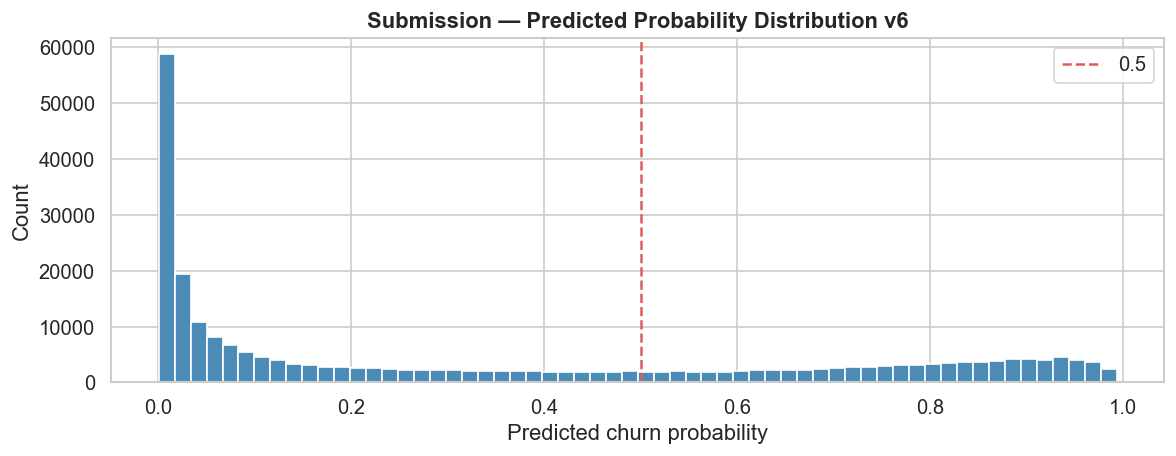


✅ Saved: /Users/clairedebadts/kaggle/customer-churn/submission_v6.csv


In [7]:
import os

submission = pd.DataFrame({
    'id'   : test_ids['id'],
    'Churn': tst_blend
})

assert submission['id'].nunique() == len(submission)
assert submission['Churn'].between(0, 1).all()
assert submission.isnull().sum().sum() == 0
print("Sanity checks: ✅")
print(f"Rows      : {len(submission):,}")
print(f"Churn mean: {submission['Churn'].mean():.4f}  (train: {y_train.mean():.4f})")
print(f"\nFinal summary:")
print(f"  LGB alone  : OOF {auc_lgb:.5f}")
print(f"  XGB alone  : OOF {auc_xgb:.5f}")
print(f"  MLP alone  : OOF {auc_mlp:.5f}")
print(f"  Blend      : OOF {auc_blend:.5f}")
print(f"  Blend weights: LGB={best_weights[0]:.2f} XGB={best_weights[1]:.2f} MLP={best_weights[2]:.2f}")
print(f"\n  Best LB so far: 0.91403 (v5ter)")
print(f"  Target        : 0.91726 (best public notebook)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(submission['Churn'], bins=60, color='#4C8BB5', edgecolor='white')
ax.axvline(0.5, color='#E05C5C', linestyle='--', linewidth=1.5, label='0.5')
ax.set_title('Submission — Predicted Probability Distribution v6', fontweight='bold')
ax.set_xlabel('Predicted churn probability')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

os.makedirs(OUT_DIR, exist_ok=True)
submission.to_csv(OUT_DIR + "submission_v6.csv", index=False)
print(f"\n✅ Saved: {OUT_DIR}submission_v6.csv")
